<a href="https://colab.research.google.com/github/suelisena/credit_card_fraud_django/blob/main/credit_card_fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import library
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Load the csv
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("/content/drive/MyDrive/Fraude_Detectetion/credit_card_fraud/transactions.csv")
print("Primeiras linhas do dataset:")
df.head()

Primeiras linhas do dataset:


,id,user_id,amount,transaction_time,location,merchant,card_type,is_fraud
0,1,1,25.50,830,New York,Amazon,Visa,0
1,2,2,4999.99,120,Los Angeles,LuxuryCars,MasterCard,1
2,3,3,75.00,1430,Chicago,Walmart,Visa,0
3,4,4,3200.00,50,Miami,RolexStore,Amex,1
4,5,5,200.00,900,Houston,BestBuy,Visa,0


In [ ]:
# Preprocessing
# Remove column with no semantic value

df = df.drop(columns=['id', 'user_id'], errors='ignore')


# Encoding categorical variables
df_encoded = pd.get_dummies(df, columns=['location', 'merchant', 'card_type'], drop_first=True)

# Separate features and target
X = df_encoded.drop(columns=['is_fraud'])
y = df_encoded['is_fraud']

# Normalize numerical values
scaler = StandardScaler()
X[['amount', 'transaction_time']] = scaler.fit_transform(X[['amount', 'transaction_time']])

# Split training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

df.head()

,amount,transaction_time,location,merchant,card_type,is_fraud
0,25.50,830,New York,Amazon,Visa,0
1,4999.99,120,Los Angeles,LuxuryCars,MasterCard,1
2,75.00,1430,Chicago,Walmart,Visa,0
3,3200.00,50,Miami,RolexStore,Amex,1
4,200.00,900,Houston,BestBuy,Visa,0


In [ ]:
# Training model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Evaluate the model
y_pred = model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.50      1.00      0.67         1

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4



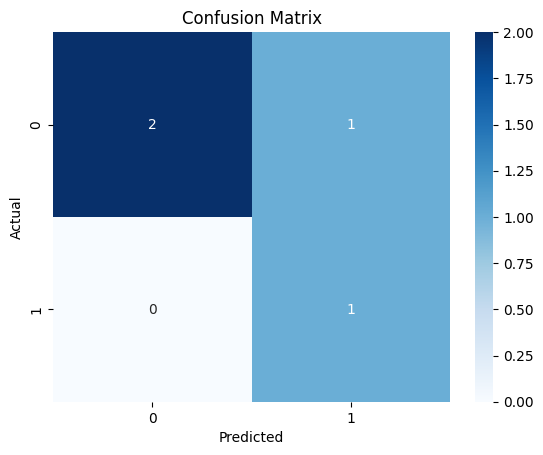

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Test a new transaction
new_transaction = pd.DataFrame([[5000, 120, 'Los Angeles', 'LuxuryCars', 'MasterCard']],
                               columns=['amount', 'transaction_time', 'location', 'merchant', 'card_type'])
# Coding is the same as in training.
new_transaction = pd.get_dummies(new_transaction, columns=['location', 'merchant', 'card_type'], drop_first=True)

# Ensure that it has the same columns as X.
new_transaction = new_transaction.reindex(columns=X.columns, fill_value=0)

# Normalize numerical values
new_transaction[['amount', 'transaction_time']] = scaler.transform(new_transaction[['amount', 'transaction_time']])

# Predicition
prediction = model.predict(new_transaction)
print("\nFraud Prediction for new transaction:", bool(prediction[0]))




Fraud Prediction for new transaction: True
